## Революция в NLP

Мы подошли к месту, где отдельные детали наконец начинают вести себя как настоящая модель.

До этого момента мы двигались правильно, но всё ещё по частям. Сначала у нас появились эмбеддинги и позиционное кодирование. Потом - SelfAttention с обучаемыми матрицами $W_Q, W_K, W_V$ где каждый токен научился не просто «быть вектором», а задавать запрос, выставлять ключ и передавать значение. Затем мы усложнили картину: вместо одной головы внимания сделали несколько, объединили их и вернули результат обратно в пространство размерности `embed_dim` через $W_O$.

После этого добавили **Feed-Forward Network** - небольшую нейросеть вида L**inear → ReLU → Linear**, которая расширяет признаки токена и затем снова сжимает их до исходного размера. Все эти части уже готовы.

**Теперь осталось самое важное: правильно собрать их в один повторяемый модуль - Transformer block. Именно из таких блоков и строится LLM.**

И это действительно центральный момент всей архитектуры. Не потому, что block - модное название, а потому, что именно здесь происходит основная работа модели. Не в эмбеддингах. Не в токенизаторе. Не в одном отдельно взятом attention. Настоящая «обработка смысла» начинается тогда, когда один и тот же поток токенов много раз проходит через одинаковые блоки: посмотрел на соседей, обновил представление, стабилизировал его, доработал признаки, передал дальше. Слой за слоем.

Проект к этому шагу нас уже подводил: предыдущие модули отдельно реализовали `attention_multihead.py` и `feed_forward.py`, а дальше логика естественно требует собрать из них **Transformer** и затем подключить выход в словарь токенов.

Один attention сам по себе - полезен, но недостаточен. Он умеет отвечать на вопрос: на кого мне сейчас посмотреть? Это важно. Но после того как токен «посмотрел» на другие токены и собрал контекст, нужно ещё решить: что мне делать с этой новой информацией? Этим уже занимается FFN.

Если сказать совсем просто, внутри блока есть две большие стадии:

**Первая стадия:** токены взаимодействуют друг с другом.
**Вторая стадия:** каждый токен по отдельности перерабатывает полученный результат.

Это очень важное разделение. Attention отвечает **за связи между токенами**. FFN отвечает за **преобразование признаков внутри каждого токена**.

В этом курсе мы будем использовать **Pre-LN** вариант блока!

Это значит, что нормализация ставится **до attention и до FFN**, а не после residual-сложения. В оригинальной статье «Attention Is All You Need» использовался Post-LN, но изучив много разных примеров, я понял, что Pre-LN обычно ведёт себя стабильнее при обучении. Поэтому для нашей простой LLM это хороший выбор.

Схема блока в нашем варианте такая:

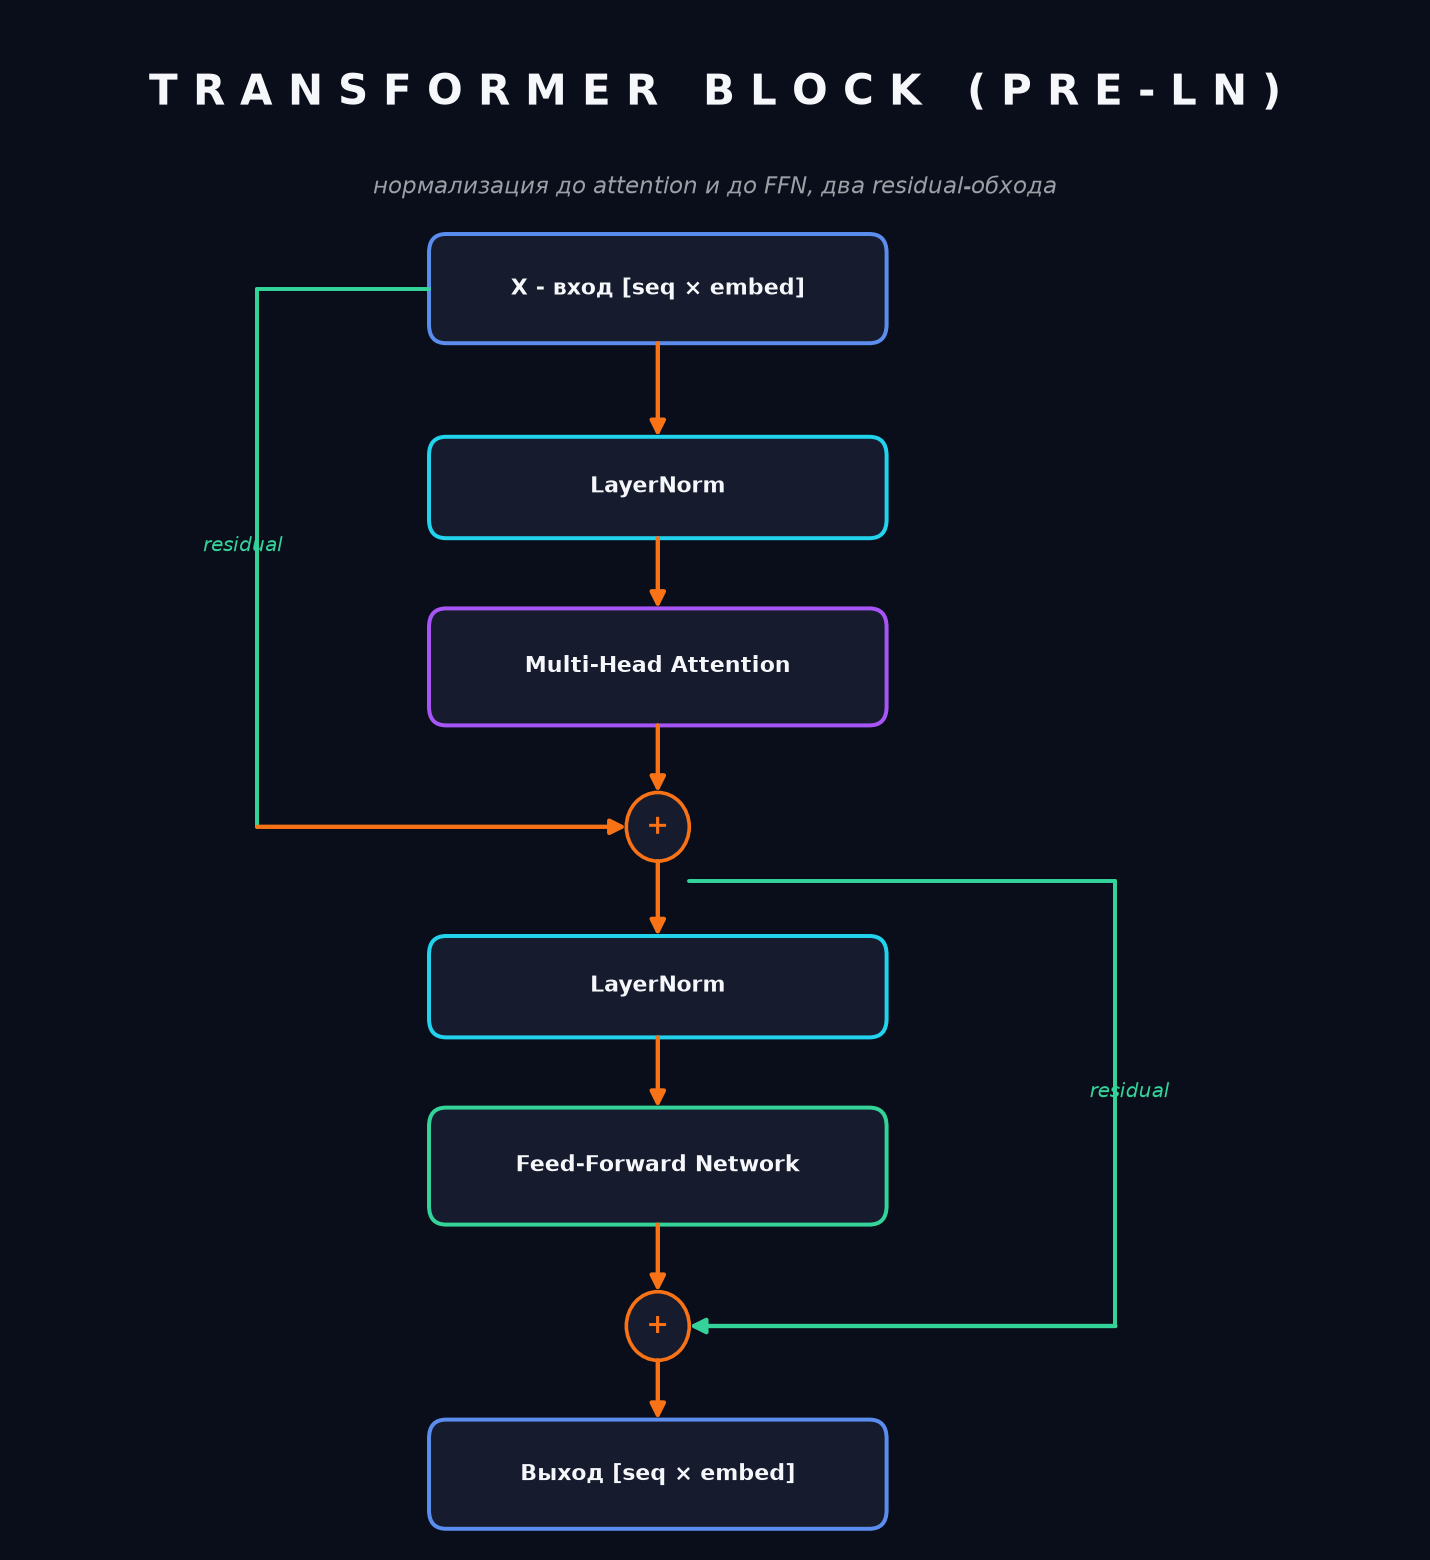

По частям:

### Multi-Head Self-Attention

Это часть, где токены смотрят друг на друга.

Мы уже подробно разбирали, что происходит внутри: из входа строятся $Q, K, V$, затем считаются $scores$, веса внимания, контекстные векторы, а несколько голов позволяют модели смотреть на последовательность сразу с нескольких точек зрения. После объединения голов применяется $W_O$ , и результат снова имеет размерность `embed_dim`.

Зачем это нужно внутри блока?

**Потому что без self-attention каждый токен был бы почти изолирован. Он мог бы знать свою позицию и свой эмбеддинг, но не мог бы учитывать, что рядом стоит подлежащее, дальше - дополнение.**

Что было бы без attention? Модель фактически потеряла бы главный механизм контекстного взаимодействия.

### Residual connection

**Residual connection** - это короткий путь, по которому вход добавляется к результату подслоя.

Если после attention мы получили `attn_output`, то residual делает так:

$$H = X + attn\_output$$

А после FFN:

$$Y = X + ffn\_output$$

На первый взгляд это выглядит почти слишком просто. Но именно в этой простоте скрыта одна из важнейших инженерных идей трансформера.

Residual connection позволяет слою учить не всю трансформацию с нуля, а только **поправку** к уже имеющемуся представлению. Это сильно облегчает обучение глубоких сетей. Слой как будто говорит: «Я не обязан полностью переписывать вход. Я могу оставить полезное как есть и добавить только то, что реально улучшает представление».

### Layer Normalization

LayerNorm нормализует признаки токена по последней размерности.

Если у токена вектор из `embed_dim` чисел, LayerNorm приводит этот набор к более стабильному масштабу: выравнивает среднее и дисперсию, а затем применяет обучаемые параметры масштаба и сдвига.

Интуитивно это нужно затем, чтобы представления не «разъезжались» по диапазонам значений от слоя к слою. Без нормализации один блок мог бы выдавать слишком крупные значения, другой - слишком мелкие, и обучение быстро стало бы нервным и нестабильным.

Что было бы без LayerNorm? Сеть могла бы всё ещё учиться, но гораздо менее предсказуемо. Особенно когда блоков становится много.

### Feed-Forward Network

**FFN** - это вторая большая стадия блока.

Мы уже разбирали её отдельно: сначала линейная проекция из embed_dim в ff_dim, затем нелинейность, затем проекция обратно в embed_dim. Это означает, что размерность на время расширяется, признаки перерабатываются, а затем снова сжимаются до размера, удобного для следующего блока.

Зачем FFN нужен, если attention уже был?

Потому что attention сам по себе в первую очередь отвечает за **обмен информацией между токенами**. Он смешивает контекст. Но после этого нужно ещё выполнить **нелинейное преобразование признаков каждого токена**. Иначе блок был бы слишком ограничен по выразительности.

Если бы оставить только attention, модель умела бы хорошо перераспределять информацию по последовательности, но ей было бы сложнее строить богатые внутренние признаки каждого токена.

### Второй residual path

После FFN мы снова добавляем исходный вход этого подэтапа:

$$Y = H + FFN(LN(H))$$

Это не повтор ради повторения. Второй residual столь же важен, как и первый. Он позволяет FFN вносить улучшения без разрушения уже накопленной информации после attention.


### Вторая нормализация
Поскольку мы используем Pre-LN, вторая нормализация стоит перед FFN, а не после сложения.

То есть у нас не:
$$LN(H+FFN(H))$$
а именно:
$$H + FFN(LN(H))$$

**Теперь давайте прогоним данные через блок так, чтобы это можно было буквально увидеть в голове.**

Пусть входной тензор имеет форму:
$$X \in R^{B\times T\times D}$$

где:

- B - batch size,
- T - длина последовательности,
- D - embed_dim

Для конкретики возьмём пример:

- batch_size = 2
- seq_length = 5
- embed_dim = 16
- num_heads = 2
- head_dim = 8
- ff_dim = 64


Тогда вход имеет форму:

$$X :  [2, 5, 16]$$


### Шаг 1. Первая нормализация

Форма не меняется:

$$[2, 5, 16] \rightarrow [2, 5, 16]$$

### Шаг 2. Multi-Head Attention

Внутри attention происходит несколько подшагов.

Сначала строятся:

$$Q = X_{norm}W_Q, K = X_{norm}W_K, V = X_{norm}W_V$$

Пока что форма всё ещё:
$$[2, 5, 16]$$
Потом тензоры разбиваются на головы:
$$Q, K, V \rightarrow [2, 2, 5, 8]$$

То есть:

* 2 объекта в батче,
* 2 головы,
* 5 токенов,
* 8 признаков на голову.

Дальше для каждой головы считаются attention scores:

$$Scores = \frac{QK^T}{\sqrt{d_k}}$$

Форма scores:
$$[2, 2, 5, 5]$$


Вот здесь важно остановиться. Матрица $5\times 5$ для каждой головы - это карта того, как **каждый токен смотрит на каждый токен**.

После softmax получаем веса внимания той же формы:
$$[2, 2, 5, 5]$$

Затем умножаем веса на $V$ и получаем контекст:

$$[2, 2, 5, 8]$$

После объединения голов:

$$[2, 5, 16]$$

После выходной проекции $W_O$:

$$attn\_output : [2, 5, 16]$$

**Обратите внимание:** `attention` внутри себя временно меняет организацию тензора, но наружу возвращает тензор той же формы, что и на входе. Именно поэтому блоки можно ставить друг за другом. Эта совместимость уже была заложена в предыдущих модулях, при реализациях `multi-head attention` и `FFN`.





### Шаг 3. Первый residual

$$H = X + attn\_output$$

Форма остаётся:
$$[2, 5, 16]$$

Что изменилось по смыслу? Теперь в каждом токене есть и его прежняя информация, и поправка, пришедшая из механизма внимания.

### Шаг 4. Вторая нормализация

$$H_{norm} = LN_2 (H)$$

Снова форма та же:

$$[2, 5, 16]$$

### Шаг 5. Feed-Forward Network

Теперь FFN работает **по каждому токену отдельно**, но одинаковыми весами для всех позиций.

Сначала:

$$H_{ff} = H_{norm}W_1 + b_1$$

Форма меняется:

$$[2, 5, 16] \rightarrow [2, 5, 64]$$

Потом нелинейность:

$$ReLU(H_{ff})$$

Форма не меняется:

$$[2, 5, 64]$$

Затем вторая линейная проекция:

$$ffn\_output = ReLU(H_{ff})W_2 + b_2$$

И форма возвращается обратно:

$$[2, 5, 64] \rightarrow [2, 5, 16]$$

### Шаг 6. Второй residual

$$Y = H + ffn\_output$$

**Это и есть выход Transformer block.**

Главный вывод из всего пути данных очень простой и очень важный:

**внутри блока вычисления могут быть сложными, но снаружи блок обязан сохранять форму $[B, T, D]$**

Именно благодаря этому мы можем взять один block и написать:

$$X(1) = Block(X(0)), X(2) = Block(X(1)), \ldots$$

Attention не «думает за токен» в полном смысле. Он не занимается глубокой нелинейной переработкой признаков. Его задача - собрать контекстную информацию: кто на кого должен посмотреть, с какими весами, и что от кого взять.

FFN, наоборот, не смотрит на соседей. Он не строит связи между токенами. Он работает уже с каждым токеном отдельно и занимается тем, что можно назвать **внутренней доработкой** представления.

Идея здесь такая:

- Attention - это разговор токенов друг с другом.
- FFN - это личное осмысление услышанного каждым токеном.

Если оставить только разговор, получится шумный коллектив без внутренней переработки.
Если оставить только личное осмысление, получится набор одиночек без обмена информацией.

Только вместе они дают то, что нам нужно для LLM.

**Теперь соберём всё вместе.**

Напоминание про attention

Пусть вход блока:

$$X \in R^{B \times T \times D}$$

Тогда для одной головы:

$$Q = XW_Q, K = XW_K, V = XW_V$$

Здесь:

* $X$ - входные представления токенов,

* $Q$ - запросы,

* $K$ - ключи,

* $V$ - значения.

Дальше:

$$Attention(Q, K, V) = softmax(\frac{QK^T}{d_k} + M)V$$

Где $M$ - маска. **Для decoder-only LLM это каузальная маска, которая запрещает смотреть в будущее.**

**Для multi-head:**

$$head_i = Attention(Q_i, K_i, V_i)$$

$$MHA(X) = Concat(head_1, \ldots, head_h)W_O$$

**Смысл здесь такой:** несколько голов параллельно строят разные контекстные представления, потом мы склеиваем их по последней размерности и пропускаем через $W_O$
 , чтобы снова получить размерность $D$.

**Формула LayerNorm**

Для одного токена с вектором $x \in R^D$

$$\mu = \frac{1}{D}\sum_{i=1}^{D}x_i$$

$$\sigma^2 = \frac{1}{D} sum_{i=1}^{D} (x_i - \mu)^2$$

$$LN(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}} + \beta$$

где:

* $\gamma$ - обучаемый масштаб

* $\beta$ - обучаемый сдвиг

* $\varepsilon$ - маленькая константа для численной стабильности

Важно: LayerNorm работает **по признакам одного токена**, а не по всей последовательности и не по батчу.

**Формула FFN**

$$FFN(x) = W_2\phi(W_1x+b_1) + b_2$$

где $\phi$ - функция активации

Сначала размерность расширяется до `ff_dim`, потом возвращается обратно к `embed_dim`.

### Полная формула блока

Поскольку мы используем Pre-LN, полный block выглядит так:

$$H = X + MHA(LN_1(X), M)$$

$$Y = H + FFN(LN_2(H))$$

Не нужно пытаться запомнить эту запись как магическое заклинание. Лучше почувствовать логику:

1. Нормализовали вход.

2. Дали токенам посмотреть друг на друга.

3. Добавили результат к исходному представлению.

4. Снова нормализовали.

5. Прогнали через маленькую нейросеть.

6. Снова добавили результат.

**Если таких блоков $L$ штук:**

$$X^{(0)} = TokenEmbedding + PositionalEncoding$$

$$X^{(l+1)} = Block_l(X^{(l)}), l = 0, 1, \ldots, L - 1$$

**После нескольких таких шагов мы получаем финальные скрытые представления токенов.**

И вот здесь появляется очень важная часть, которую легко недооценить: **output layer**.

Transformer block сам по себе не предсказывает токен из словаря. Он только строит скрытые представления.

Чтобы превратить эти представления в прогноз по словарю, нужна линейная проекция:

$$logits = X_{final}W_{vocab} + b$$

Если

$$X_{final} \in R^{B \times T \times D}$$

а размер словаря V:

$W_{vocab} \in R^{D \times V}$

и на выходе получаем:

$$logits \in R^{B \times T \times V}$$

**Это значит: для каждого токена в каждой позиции модель выдаёт по одному числу на каждый токен словаря.**

Именно эти числа потом превращаются в вероятности через **softmax**:

$$p = softmax(logits)$$

Но важная практическая деталь: во время обучения мы обычно передаём в loss именно **logits**, без предварительного softmax.

**Перейдём к реализации.**

Первая - `MultiHeadAttention` из `attention_multihead.py`. Мы уже реализовали в нём все главные шаги: проекции $Q, K, V$, разбиение на головы, вычисление attention, объединение голов и финальную проекцию $W_O$.

Важно и то, что этот слой возвращает тензор той же формы, что и на входе: `[batch_size, seq_length, embed_dim]`. Это было отдельно проверено в тестах.

Вторая - `FeedForwardNetwork` из `feed_forward.py`. Мы уже сделали её как простой MLP: `Linear → ReLU → Linear`. Внутри FFN размерность временно расширяется до `ff_dim`, а затем возвращается обратно к `embed_dim`, так что внешний формат данных снова сохраняется. При этом FFN обрабатывает каждый токен независимо, не смешивая их между собой.

Сначала соберём сам **Transformer block**
Мы будем использовать вариант **Pre-LN**, который уже обсудили в математической части. Это значит:

- сначала делаем LayerNorm,

- потом attention,

- потом residual connection,

- затем снова LayerNorm,

- потом FFN,

- потом второй residual connection.

Именно в таком порядке.



Реализуем в `transformer_block.py`.

Сам по себе один **Transformer block** - это уже очень важный модуль, но это ещё не вся модель. Чтобы получить простую LLM, нужно добавить:

- токен-эмбеддинги,

- позиционные эмбеддинги,

- стек из нескольких Transformer blocks,

- финальную нормализацию,

- выходной слой lm_head, который переводит скрытые представления в logits по словарю.

Вот здесь как раз появляется Output Layer.

Это сделаем в `model.py`

Очень полезно после реализации сделать не полноценное обучение, а хотя бы простой прогон вперёд - `test_model_shapes.py`